# Model selection and cross-validation

Why training-set fit is a biased guide to model quality (it always improves with complexity), and the three standard cures: penalized-likelihood information criteria (AIC/BIC), k-fold cross-validation, and the one-standard-error rule for parsimony. We choose the degree of a polynomial regression - the cleanest possible setting, with a unique least-squares fit at every complexity - and watch each signal behave.


## Generalization error and the optimism of training fit

Fix a loss; for densities use the deviance (twice the negative log-likelihood). Training error is
$\overline{\mathrm{err}} = \tfrac1n\sum_i \mathrm{loss}(x_i,\hat\theta)$, evaluated on the same data used
to fit $\hat\theta$. Test error is the expected loss on a fresh independent observation. Because $\hat\theta$
was tuned to the training points, training error is optimistic: it underestimates test error.

Theorem (optimism). For models fit by maximum likelihood, the expected gap between test and training
deviance is, to leading order, $2k/n$, where $k$ is the number of free parameters (more precisely the
effective degrees of freedom). Equivalently
$$\mathbb E[\text{test deviance}] \approx \mathbb E[\text{train deviance}] + 2k/n.$$

Proof idea. Expand the test deviance around $\hat\theta$ and take expectations; the cross term between
the estimation error $\hat\theta-\theta_0$ and the score contributes, by asymptotic normality and the
information identity, a penalty proportional to $\mathrm{tr}(\mathcal I^{-1}\mathcal I)=k$. This optimism
is what every selection criterion tries to undo.

## AIC, BIC, and what each one estimates

Akaike Information Criterion. Adding the optimism penalty to the deviance gives
$$\mathrm{AIC} = -2\,\ell(\hat\theta) + 2k.$$
AIC is an estimate of the expected out-of-sample deviance, equivalently of the Kullback-Leibler distance
from the truth to the fitted model up to a constant. Minimizing AIC targets prediction accuracy.

Bayesian Information Criterion. BIC comes from a Laplace approximation to the log marginal likelihood
$\log\int p(x\mid\theta)\pi(\theta)d\theta$. Expanding the integrand around $\hat\theta$ and doing the
Gaussian integral gives
$$\log p(\text{data}) \approx \ell(\hat\theta) - \tfrac{k}{2}\log n + O(1),
  \qquad\text{so}\qquad \mathrm{BIC} = -2\,\ell(\hat\theta) + k\log n.$$
BIC approximates $-2\log$ of the model evidence, so differences in BIC approximate log Bayes factors.

The two penalties differ only in the per-parameter cost: $2$ for AIC, $\log n$ for BIC. For $n>7$ BIC
penalizes complexity more heavily, so it prefers smaller models.

Theorem (consistency vs efficiency). If the true model is among the candidates, BIC selects it with
probability tending to one (it is selection-consistent), while AIC retains a positive probability of
overfitting even as $n\to\infty$. If the true model is not among the candidates, AIC is asymptotically
efficient: it selects the candidate minimizing prediction risk, which BIC may under-select.

Proof idea. For a true-versus-overfit comparison the deviance improvement from an extra useless parameter
is $O_p(1)$ (a chi-squared variable), while the penalty difference is $2$ for AIC (comparable, so AIC
overfits with constant probability) but $\log n\to\infty$ for BIC (eventually dominates, so BIC stops
overfitting). The efficiency claim for AIC follows from its unbiased estimation of predictive risk.

## Cross-validation and the one-standard-error rule

Definition (K-fold cross-validation). Split the data into $K$ folds; for each fold, fit on the other
$K-1$ and score on the held-out fold; average. Leave-one-out (LOO) is $K=n$. Cross-validation estimates
test error directly, making no parametric assumption about the optimism.

For linear-Gaussian models LOO cross-validation is asymptotically equivalent to AIC, which links the two
viewpoints: the analytic penalty and the resampling estimate agree in the regime where both are valid.

The one-standard-error rule chooses the simplest model whose cross-validated error is within one standard
error of the minimum. It guards against the noise in the cross-validation estimate itself and favors
parsimony, which usually generalizes better than chasing the exact minimum.

Counterexample (AIC is not consistent). Even with the true model in the candidate set and unlimited data,
AIC keeps selecting an over-large model with constant positive probability, because its penalty does not
grow with $n$. BIC does not have this problem. The cost is symmetric: if the truth is more complex than
any candidate, BIC's heavier penalty can under-select. We demonstrate the AIC-versus-BIC difference
below.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
rng = np.random.RandomState(0)

# Least-squares polynomial fitting IS Gaussian maximum likelihood, so we can score
# any degree by its Gaussian log-likelihood and compare AIC/BIC/CV on one footing.
def gaussian_ll(resid):
    n = len(resid); sigma2 = np.sum(resid ** 2) / n          # MLE noise variance
    return -0.5 * n * (np.log(2 * np.pi * sigma2) + 1)

def fit_score(x_tr, y_tr, x_te, y_te, degree):
    coef = np.polyfit(x_tr, y_tr, degree)                    # unique least-squares solution
    return gaussian_ll(y_te - np.polyval(coef, x_te)), coef

## 1. Overfitting: why training fit lies

We generate data from a cubic ($K^\star=3$) plus Gaussian noise and fit polynomials of every degree from 0 to 9. A higher-degree polynomial can always fit the training points at least as well - by degree 9 it wiggles through the noise. So "the degree with the highest training likelihood" is a recipe for overfitting; we need a score that either penalizes complexity or measures generalization.


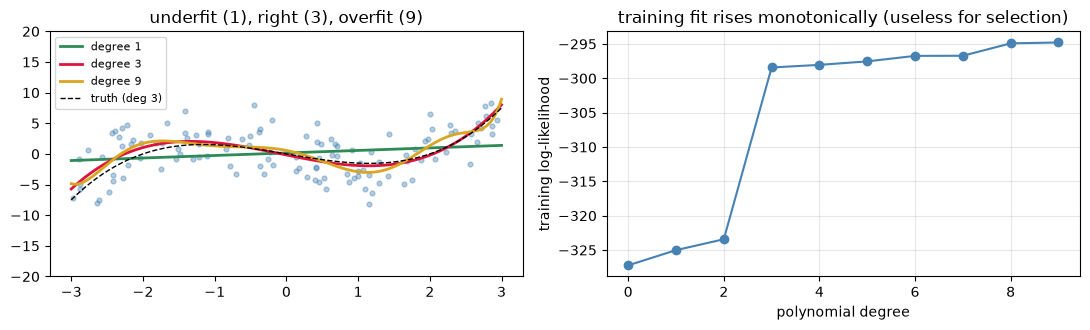

In [2]:
n = 120
x = np.sort(rng.uniform(-3, 3, n))
true_fn = lambda t: 0.5 * t ** 3 - 2 * t
y = true_fn(x) + rng.normal(0, 3.0, n)

degrees = list(range(0, 10))
train_ll = [fit_score(x, y, x, y, d)[0] for d in degrees]

grid = np.linspace(-3, 3, 200)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].scatter(x, y, s=12, alpha=0.4, color='steelblue')
for d, c in [(1, 'seagreen'), (3, 'crimson'), (9, 'goldenrod')]:
    ax[0].plot(grid, np.polyval(np.polyfit(x, y, d), grid), color=c, lw=2, label='degree %d' % d)
ax[0].plot(grid, true_fn(grid), 'k--', lw=1, label='truth (deg 3)')
ax[0].set_title('underfit (1), right (3), overfit (9)'); ax[0].legend(fontsize=8); ax[0].set_ylim(-20, 20)
ax[1].plot(degrees, train_ll, 'o-', color='steelblue'); ax[1].set_xlabel('polynomial degree')
ax[1].set_ylabel('training log-likelihood'); ax[1].grid(alpha=0.3)
ax[1].set_title('training fit rises monotonically (useless for selection)')
plt.tight_layout(); plt.show()

## 2. Information criteria: penalized likelihood

AIC and BIC add a penalty for the number of free parameters $p$ (here $p = (\text{degree}+1)$ coefficients $+\,1$ noise variance):

$$\mathrm{AIC} = 2p - 2\ell, \qquad \mathrm{BIC} = p\ln n - 2\ell,$$

with $\ell$ the maximized log-likelihood (lower criterion is better). BIC's penalty grows with $n$, so it leans simpler and is consistent (recovers the true model as $n\to\infty$); AIC targets predictive accuracy and tends slightly richer. Both need only the training fit.


In [3]:
p = np.array([d + 2 for d in degrees])           # (degree+1) coeffs + noise variance
aic = 2 * p - 2 * np.array(train_ll)
bic = p * np.log(n) - 2 * np.array(train_ll)
print('AIC picks degree %d ; BIC picks degree %d  (truth = 3)'
      % (degrees[int(np.argmin(aic))], degrees[int(np.argmin(bic))]))

AIC picks degree 3 ; BIC picks degree 3  (truth = 3)


## 3. k-fold cross-validation, with the one-standard-error rule

Cross-validation assumes no formula: split into $k$ folds, train on $k-1$, score the held-out fold, rotate, average - an estimate of out-of-sample performance for any model. We compute it per fold so we also get a standard error. CV curves often plateau once complexity is adequate (extra capacity neither helps nor hurts much), so the raw argmax can drift one step past the truth. The one-standard-error rule restores parsimony: among models within one SE of the best, take the simplest.


In [4]:
def kfold(degree, k=5):
    idx = rng.permutation(n); folds = np.array_split(idx, k); per_fold = []
    for f in folds:
        fset = set(f.tolist()); tr = [i for i in idx if i not in fset]
        ll, _ = fit_score(x[tr], y[tr], x[f], y[f], degree)
        per_fold.append(ll / len(f))                 # per-point held-out log-likelihood
    return np.array(per_fold)

cv = {d: kfold(d) for d in degrees}
cv_mean = np.array([cv[d].mean() for d in degrees])
cv_se = np.array([cv[d].std(ddof=1) / np.sqrt(len(cv[d])) for d in degrees])
best = int(np.argmax(cv_mean)); threshold = cv_mean[best] - cv_se[best]
one_se = degrees[next(i for i in degrees if cv_mean[i] >= threshold)]
print('raw argmax CV: degree %d ; one-SE rule: degree %d' % (degrees[best], one_se))

raw argmax CV: degree 4 ; one-SE rule: degree 3


## 4. Putting it together

All signals on one figure. Training likelihood climbs forever - never select on it. AIC and BIC turn around at the true degree 3. CV rises then plateaus; its raw peak may sit at 3-4, and the one-standard-error rule (dashed = best $-$ 1 SE; pick the leftmost point above it) lands on 3. The discipline: never trust training fit, use AIC/BIC as cheap analytic proxies, and treat CV as the model-agnostic gold standard with a parsimony rule.


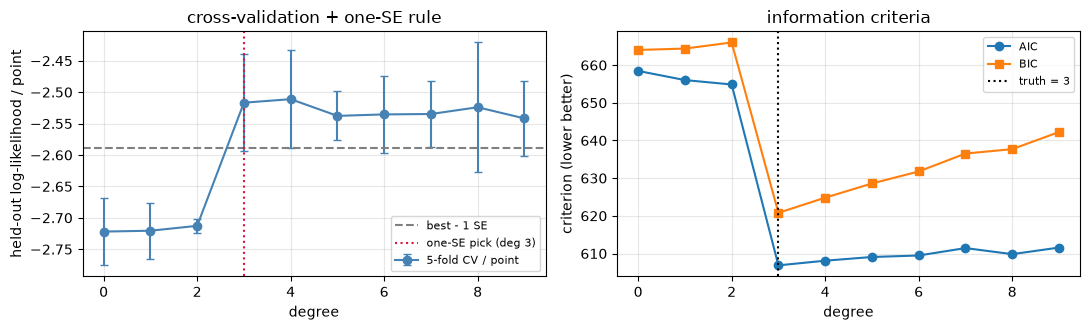

selected degree -> train:9  AIC:3  BIC:3  CV(1-SE):3  (truth=3)


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].errorbar(degrees, cv_mean, yerr=cv_se, fmt='o-', color='steelblue', capsize=3, label='5-fold CV / point')
ax[0].axhline(threshold, color='gray', ls='--', label='best - 1 SE')
ax[0].axvline(one_se, color='crimson', ls=':', label='one-SE pick (deg %d)' % one_se)
ax[0].set_xlabel('degree'); ax[0].set_ylabel('held-out log-likelihood / point'); ax[0].legend(fontsize=8)
ax[0].set_title('cross-validation + one-SE rule'); ax[0].grid(alpha=0.3)
ax[1].plot(degrees, aic, 'o-', label='AIC'); ax[1].plot(degrees, bic, 's-', label='BIC')
ax[1].axvline(3, color='k', ls=':', label='truth = 3'); ax[1].set_xlabel('degree')
ax[1].set_ylabel('criterion (lower better)'); ax[1].legend(fontsize=8); ax[1].set_title('information criteria'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('selected degree -> train:%d  AIC:%d  BIC:%d  CV(1-SE):%d  (truth=3)' % (
    degrees[int(np.argmax(train_ll))], degrees[int(np.argmin(aic))], degrees[int(np.argmin(bic))], one_se))

## Nested cross-validation when you select and report

If you choose the model by CV and then report that same CV score as the model's performance, the estimate is optimistically biased - you peeked. Nested CV quarantines selection (inner loop) from evaluation (outer loop). We compare flat CV, nested CV, and a held-out test set; the flat-CV number is too rosy.


In [6]:
x_all = np.sort(rng.uniform(-3, 3, 200)); y_all = true_fn(x_all) + rng.normal(0, 3.0, 200)
test_mask = rng.rand(200) < 0.3
xtr, ytr, xte, yte = x_all[~test_mask], y_all[~test_mask], x_all[test_mask], y_all[test_mask]
cand = list(range(0, 8))

def cv_select(x, y, k=5):                          # inner: pick the degree by CV
    idx = rng.permutation(len(x)); folds = np.array_split(idx, k); sc = []
    for d in cand:
        tot = 0.0
        for f in folds:
            tr = [i for i in idx if i not in set(f.tolist())]
            tot += gaussian_ll(y[f] - np.polyval(np.polyfit(x[tr], y[tr], d), x[f]))
        sc.append(tot)
    return cand[int(np.argmax(sc))]

best_d = cv_select(xtr, ytr); flat = []
idx = rng.permutation(len(xtr))
for f in np.array_split(idx, 5):
    tr = [i for i in idx if i not in set(f.tolist())]
    flat.append(gaussian_ll(ytr[f] - np.polyval(np.polyfit(xtr[tr], ytr[tr], best_d), xtr[f])) / len(f))
nested = []
oidx = rng.permutation(len(xtr))
for f in np.array_split(oidx, 5):
    tr = np.array([i for i in oidx if i not in set(f.tolist())])
    d = cv_select(xtr[tr], ytr[tr])
    nested.append(gaussian_ll(ytr[f] - np.polyval(np.polyfit(xtr[tr], ytr[tr], d), xtr[f])) / len(f))
test_ll = gaussian_ll(yte - np.polyval(np.polyfit(xtr, ytr, best_d), xte)) / len(yte)
print('selected degree: %d (truth 3)' % best_d)
print('flat-CV per-point LL   : %.3f  <- optimistic (selection peeked)' % np.mean(flat))
print('nested-CV per-point LL : %.3f' % np.mean(nested))
print('held-out test LL       : %.3f  <- the honest number' % test_ll)

selected degree: 4 (truth 3)
flat-CV per-point LL   : -2.495  <- optimistic (selection peeked)
nested-CV per-point LL : -2.518
held-out test LL       : -2.613  <- the honest number


## Illustration: AIC overfits, BIC is consistent

We generate data from a known polynomial degree, fit candidate degrees by maximum likelihood, and select
by AIC and by BIC over many datasets at growing sample sizes. With the true model in the candidate set,
BIC's selection of the correct degree tends to one, while AIC keeps overselecting at a roughly constant
rate, exactly as the consistency theorem predicts.

In [7]:
rng = np.random.RandomState(0)
true_deg, sigma = 2, 1.0
coef = np.array([1.0, -2.0, 1.5])                            # quadratic truth
def gauss_loglik(y, yhat, k):
    resid = y - yhat; s2 = np.mean(resid ** 2)
    return -0.5 * len(y) * (np.log(2 * np.pi * s2) + 1)      # profile log-likelihood at MLE sigma
def select(n, trials=400):
    aic_correct = bic_correct = aic_over = 0
    for _ in range(trials):
        x = rng.uniform(-2, 2, n)
        y = coef[0] + coef[1] * x + coef[2] * x ** 2 + rng.normal(0, sigma, n)
        aics, bics = [], []
        for d in range(0, 6):
            yhat = np.polyval(np.polyfit(x, y, d), x)
            k = d + 2                                         # d+1 coefficients plus sigma
            ll = gauss_loglik(y, yhat, k)
            aics.append(-2 * ll + 2 * k); bics.append(-2 * ll + k * np.log(n))
        da, db = int(np.argmin(aics)), int(np.argmin(bics))
        aic_correct += (da == true_deg); bic_correct += (db == true_deg); aic_over += (da > true_deg)
    return aic_correct / trials, bic_correct / trials, aic_over / trials
print(' n     AIC picks true   BIC picks true   AIC overfits')
for n in [50, 200, 1000, 5000]:
    ac, bc, ao = select(n)
    print(' %5d      %.2f             %.2f            %.2f' % (n, ac, bc, ao))
print('BIC -> 1 as n grows (consistent); AIC keeps a steady overfitting rate (not consistent).')

 n     AIC picks true   BIC picks true   AIC overfits


    50      0.74             0.93            0.26


   200      0.75             0.96            0.25


  1000      0.76             0.99            0.24


  5000      0.75             1.00            0.25
BIC -> 1 as n grows (consistent); AIC keeps a steady overfitting rate (not consistent).


## References

- Akaike, H. (1974). A new look at the statistical model identification (https://doi.org/10.1109/TAC.1974.1100705). IEEE TAC 19(6), 716-723. - AIC.
- Schwarz, G. (1978). Estimating the dimension of a model (https://doi.org/10.1214/aos/1176344136). Ann. Statist. 6(2), 461-464. - BIC.
- Stone, M. (1974). Cross-validatory choice and assessment of statistical predictions (https://doi.org/10.1111/j.2517-6161.1974.tb00994.x). JRSS-B 36(2), 111-147.
- Arlot, S. & Celisse, A. (2010). A survey of cross-validation procedures for model selection (https://doi.org/10.1214/09-SS054). Statist. Surveys 4, 40-79.
- Hastie, T., Tibshirani, R. & Friedman, J. (2009). The Elements of Statistical Learning (https://hastie.su.domains/ElemStatLearn/), 2nd ed. Springer. - the one-standard-error rule (§7).
- Vehtari, A., Gelman, A. & Gabry, J. (2017). Practical Bayesian model evaluation using leave-one-out cross-validation and WAIC (https://doi.org/10.1007/s11222-016-9696-4). Stat. Comput. 27, 1413-1432.


## Exercises and extensions

1. Nested cross-validation done right. When you both select a model and report its performance, a single CV loop is optimistically biased. Implement nested CV (inner loop selects the polynomial degree / mixture $K$, outer loop estimates generalization) and quantify the optimism of flat CV by comparing the two estimates against a large held-out test set. Write up the size of the selection bias.
2. AIC vs BIC: consistency vs efficiency. Design two simulation studies - one where the true model is in the candidate set (BIC should win, recovering it as $n\to\infty$) and one where it is not (AIC should win predictively). Plot selection frequency and predictive risk vs $n$ for both criteria; state the regime each is built for (efficiency vs consistency).
3. Repeated and stratified CV variance. Estimate the variance of $k$-fold CV as a function of $k$ and of repetition count; show why 5×2 or repeated 10-fold is more stable than a single 10-fold, and how the one-standard-error rule (Hastie et al.) uses that variance to pick a parsimonious model.
4. Information criteria for Bayesian models. For a `mixle.ppl` mixture/hierarchical model, compute WAIC and PSIS-LOO (Vehtari et al.) from the pointwise log-likelihood and compare the selected complexity to AIC/BIC/CV. Discuss when fully-Bayesian model evaluation is worth the cost.
